In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
print('Libraries imported successfully')

Libraries imported successfully


Step 1: Load the Dataset

In [2]:
df = pd.read_csv('train.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nNumber of rows    : {df.shape[0]}')
print(f'Number of columns : {df.shape[1]}')
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1460, 81)

Number of rows    : 1460
Number of columns : 81

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print('Data Types Summary:')
print(df.dtypes.value_counts())
print('\nTarget Variable (SalePrice) Statistics:')
print(df['SalePrice'].describe())

Data Types Summary:
object     43
int64      35
float64     3
Name: count, dtype: int64

Target Variable (SalePrice) Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Identify Missing Values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Columns with Missing Values:')
print(missing_df)

Columns with Missing Values:
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtFinType2             38       2.60
BsmtExposure             38       2.60
BsmtFinType1             37       2.53
BsmtCond                 37       2.53
BsmtQual                 37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


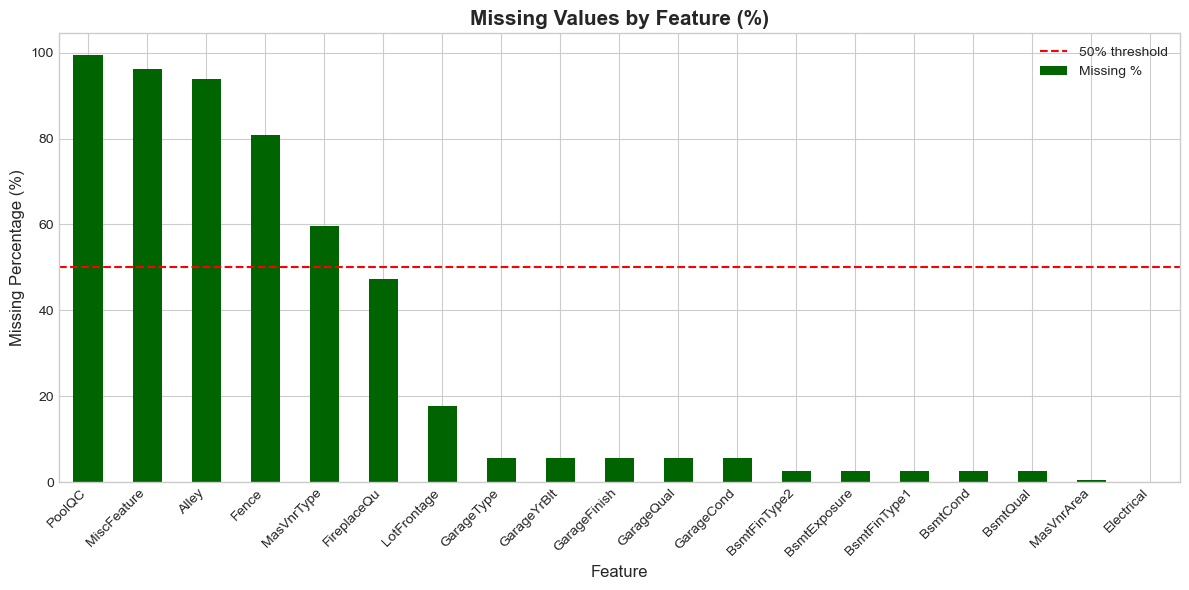

Missing values visualisation


In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
missing_df['Missing %'].plot(kind='bar', color='#006400', ax=ax)
ax.set_title('Missing Values by Feature (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Missing Percentage (%)', fontsize=12)
ax.axhline(y=50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Missing values visualisation')

Handle Missing Values

In [6]:
df_clean = df.copy()

high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f'Columns dropped (>50% missing): {high_missing}')
df_clean.drop(columns=high_missing, inplace=True)

cat_cols = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('None')


num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

print(f'\nMissing values after cleaning: {df_clean.isnull().sum().sum()}')
print(f'Dataset shape after cleaning : {df_clean.shape}')

Columns dropped (>50% missing): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

Missing values after cleaning: 0
Dataset shape after cleaning : (1460, 76)


Remove Outliers

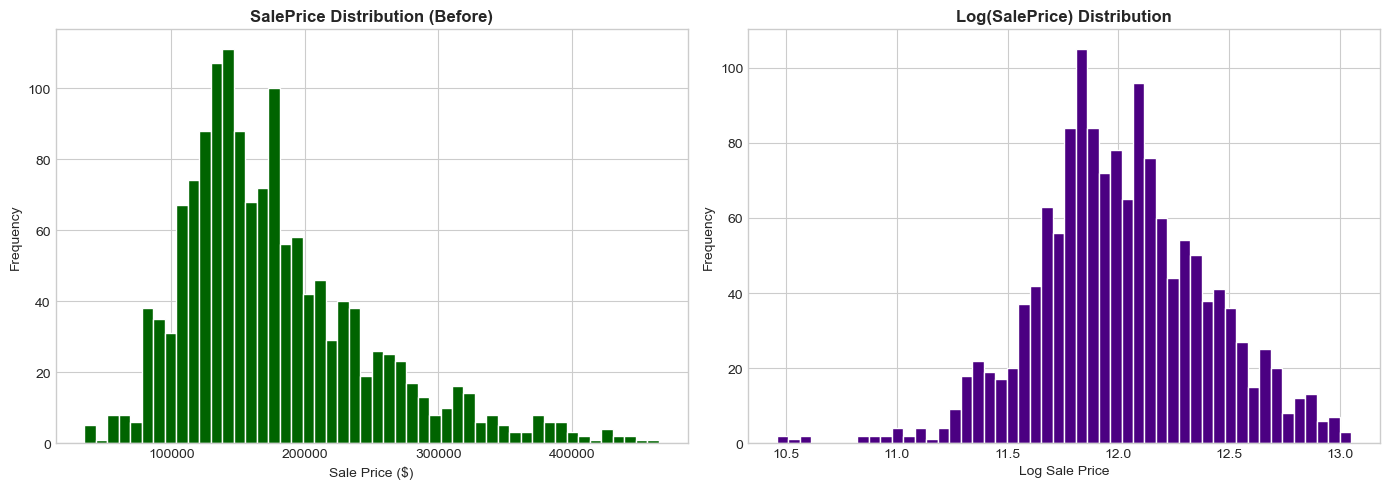

Figure 2: SalePrice distribution before and after log transformation


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['SalePrice'], bins=50, color='#006400', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Before)', fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df_clean['SalePrice']), bins=50, color='#4B0082', edgecolor='white')
axes[1].set_title('Log(SalePrice) Distribution', fontweight='bold')
axes[1].set_xlabel('Log Sale Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print('Figure 2: SalePrice distribution before and after log transformation')

In [8]:
Q1 = df_clean['SalePrice'].quantile(0.25)
Q3 = df_clean['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

before = len(df_clean)
df_clean = df_clean[(df_clean['SalePrice'] >= lower) & (df_clean['SalePrice'] <= upper)]
after = len(df_clean)
print(f'Rows removed as outliers: {before - after}')
print(f'Rows remaining          : {after}')

Rows removed as outliers: 12
Rows remaining          : 1448


Decode Categorical Features

In [9]:
df_encoded = df_clean.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include='object').columns
print(f'Encoding {len(cat_cols)} categorical columns...')
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print('Encoding complete!')
print(f'Dataset shape: {df_encoded.shape}')

Encoding 38 categorical columns...
Encoding complete!
Dataset shape: (1448, 76)


 Data Visualization

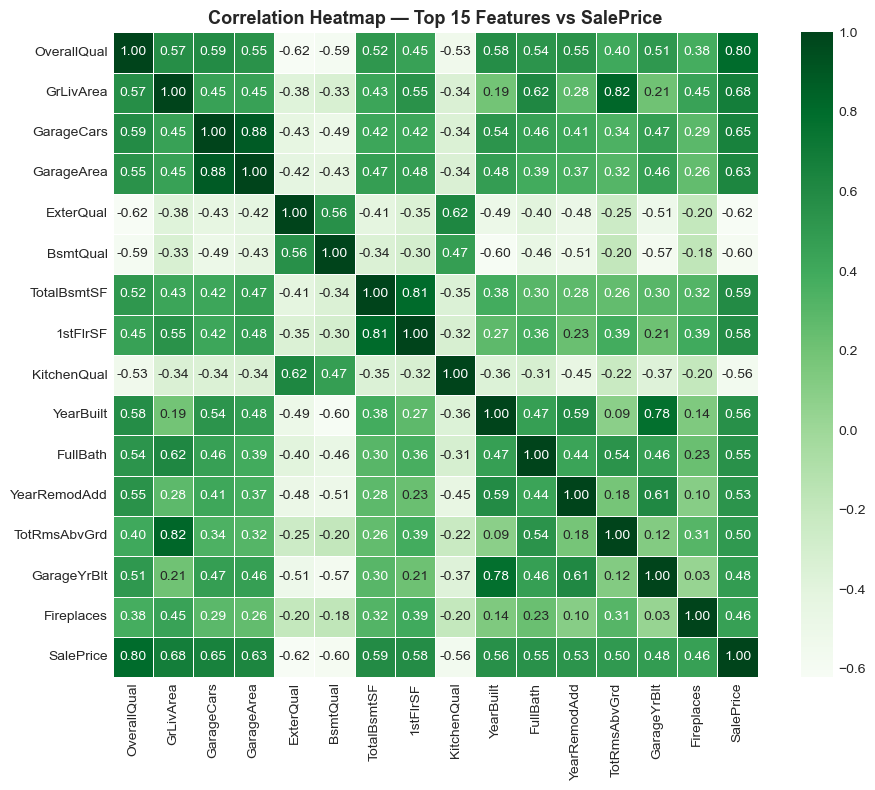

Correlation heatmap


In [30]:
num_df = df_encoded.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = corr[1:16].index.tolist()  # top 15 features

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = num_df[top_features + ['SalePrice']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Greens', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top 15 Features vs SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Correlation heatmap')

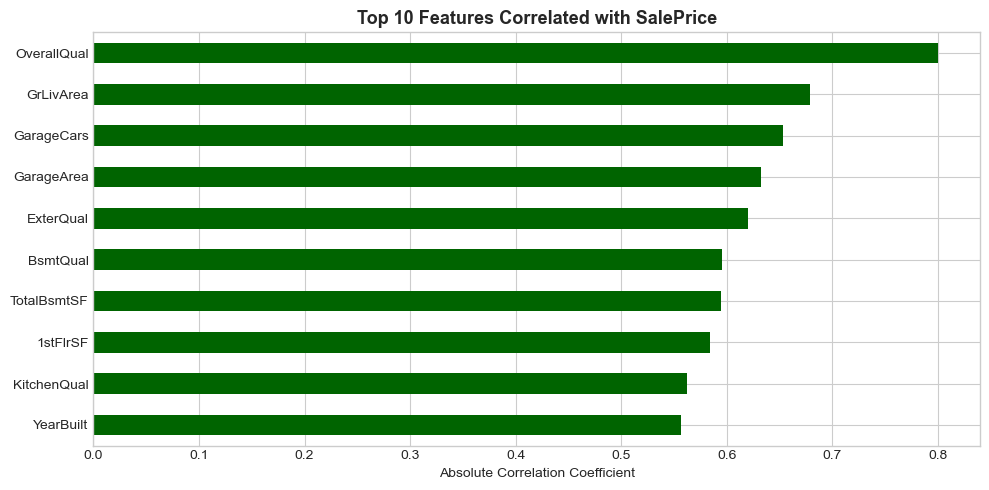

Top 10 correlated features


In [31]:
top_corr = corr[1:11]
fig, ax = plt.subplots(figsize=(10, 5))
top_corr.sort_values().plot(kind='barh', color='#006400', ax=ax)
ax.set_title('Top 10 Features Correlated with SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Correlation Coefficient')
plt.tight_layout()
plt.show()
print('Top 10 correlated features')

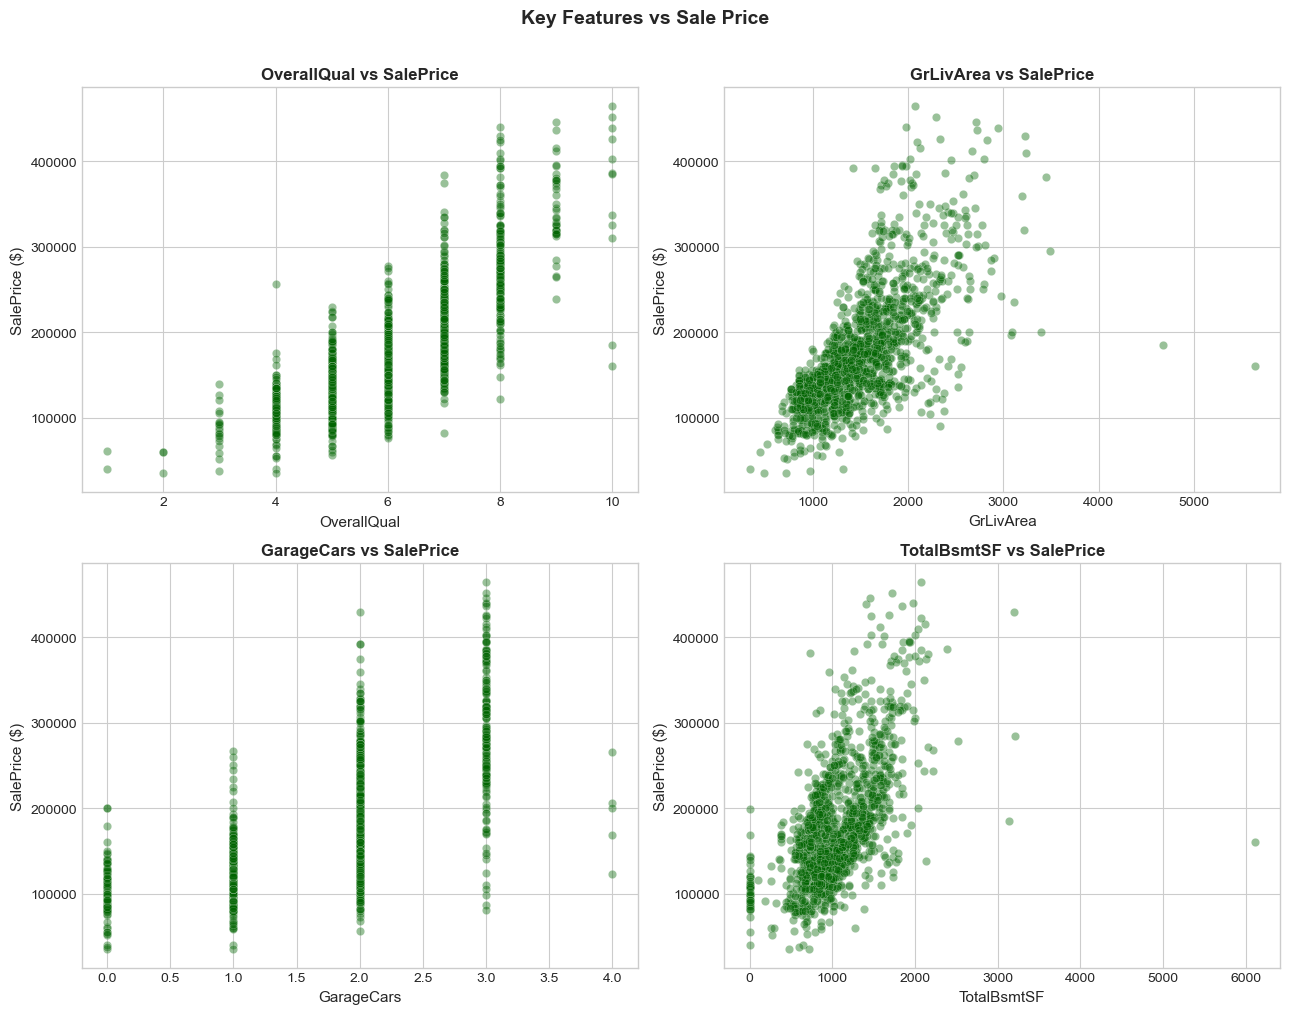

Scatter plots of key features vs SalePrice


In [32]:
top4 = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, feat in zip(axes.flatten(), top4):
    ax.scatter(df_clean[feat], df_clean['SalePrice'], alpha=0.4, color='#006400', edgecolors='white', linewidths=0.3)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SalePrice ($)', fontsize=11)
    ax.set_title(f'{feat} vs SalePrice', fontweight='bold')

plt.suptitle('Key Features vs Sale Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Scatter plots of key features vs SalePrice')

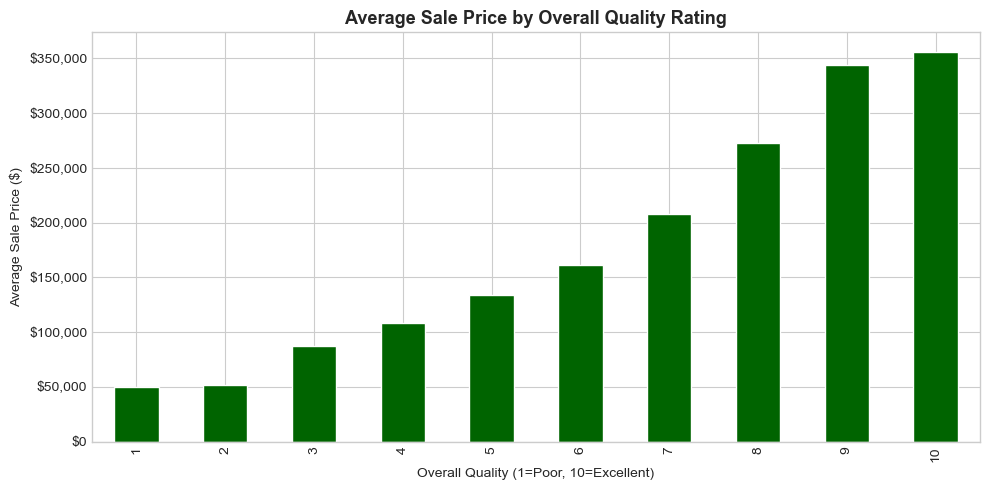

Average sale price by quality rating


In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
avg_price = df_clean.groupby('OverallQual')['SalePrice'].mean().sort_index()
avg_price.plot(kind='bar', color='#006400', ax=ax, edgecolor='white')
ax.set_title('Average Sale Price by Overall Quality Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Overall Quality (1=Poor, 10=Excellent)')
ax.set_ylabel('Average Sale Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print('Average sale price by quality rating')

Feature Selection and Data Split

In [14]:
selected_features = corr[1:21].index.tolist() 
print(f'Selected {len(selected_features)} features for modelling:')
print(selected_features)

X = df_encoded[selected_features]
y = df_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTraining set  : {X_train.shape}')
print(f'Test set      : {X_test.shape}')

Selected 20 features for modelling:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'ExterQual', 'BsmtQual', 'TotalBsmtSF', '1stFlrSF', 'KitchenQual', 'YearBuilt', 'FullBath', 'YearRemodAdd', 'TotRmsAbvGrd', 'GarageYrBlt', 'Fireplaces', 'GarageType', 'GarageFinish', 'MasVnrArea', 'HeatingQC', 'Foundation']

Training set  : (1158, 20)
Test set      : (290, 20)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Feature scaling complete!')

Feature scaling complete!


Linear Regression

In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Linear Regression Results ===')
print(f'RMSE : ${rmse_lr:,.2f}')
print(f'MAE  : ${mae_lr:,.2f}')
print(f'R²   : {r2_lr:.4f}')

=== Linear Regression Results ===
RMSE : $26,707.33
MAE  : $20,706.68
R²   : 0.7955


Random Forest Regressor

In [17]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor Results ===')
print(f'RMSE : ${rmse_rf:,.2f}')
print(f'MAE  : ${mae_rf:,.2f}')
print(f'R²   : {r2_rf:.4f}')

=== Random Forest Regressor Results ===
RMSE : $24,939.70
MAE  : $17,278.23
R²   : 0.8217


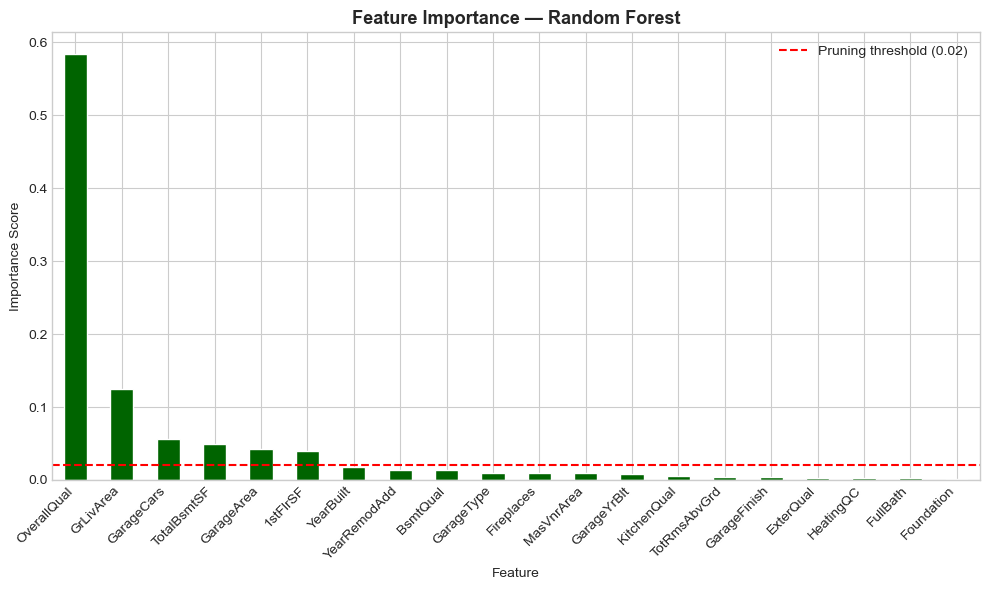

Feature importance scores


In [35]:
importances = pd.Series(rf.feature_importances_, index=selected_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='bar', color='#006400', ax=ax, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance Score')
ax.axhline(y=0.02, color='red', linestyle='--', label='Pruning threshold (0.02)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Feature importance scores')

In [19]:
important_features = importances[importances > 0.02].index.tolist()
print(f'Features kept after pruning: {len(important_features)}')
print(important_features)

X_train_pruned = X_train[important_features]
X_test_pruned  = X_test[important_features]

rf_pruned = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                                   random_state=42, n_jobs=-1)
rf_pruned.fit(X_train_pruned, y_train)
y_pred_pruned = rf_pruned.predict(X_test_pruned)

rmse_p = np.sqrt(mean_squared_error(y_test, y_pred_pruned))
mae_p  = mean_absolute_error(y_test, y_pred_pruned)
r2_p   = r2_score(y_test, y_pred_pruned)

print(f'\n=== Pruned Random Forest Results ===')
print(f'RMSE : ${rmse_p:,.2f}')
print(f'MAE  : ${mae_p:,.2f}')
print(f'R²   : {r2_p:.4f}')

Features kept after pruning: 6
['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

=== Pruned Random Forest Results ===
RMSE : $27,066.73
MAE  : $19,425.16
R²   : 0.7900


Filter Noisy Predictions

In [20]:
residuals = y_test - y_pred_pruned
std_res = residuals.std()

noisy_mask = np.abs(residuals) > 2 * std_res
print(f'Total predictions : {len(y_test)}')
print(f'Noisy predictions : {noisy_mask.sum()} ({noisy_mask.mean()*100:.1f}%)')
print(f'Clean predictions : {(~noisy_mask).sum()}')

Total predictions : 290
Noisy predictions : 14 (4.8%)
Clean predictions : 276


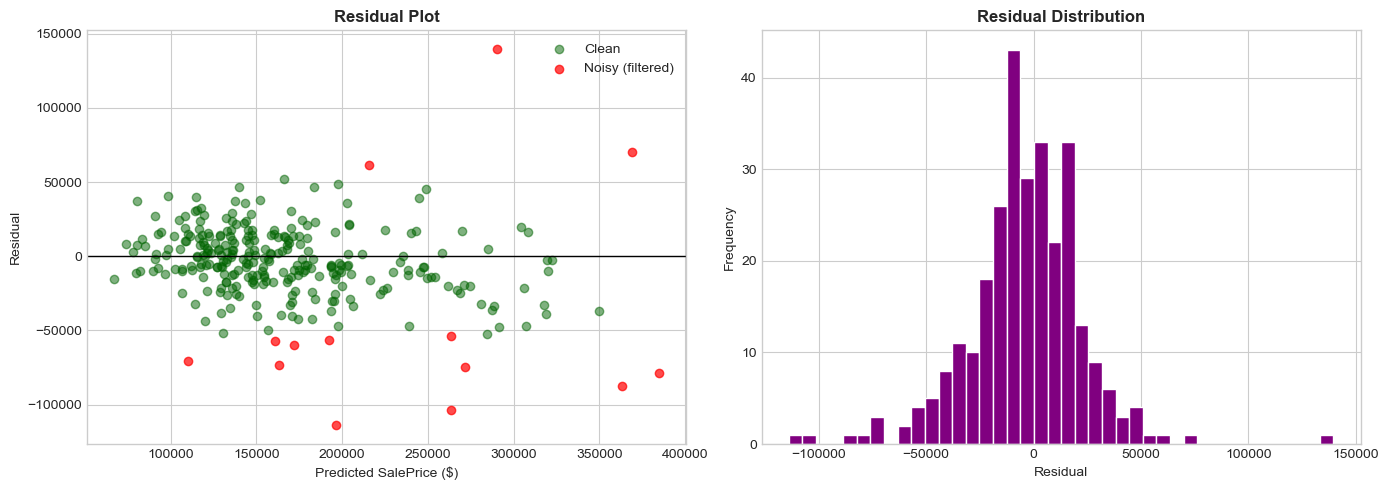

Residual analysis


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_pruned[~noisy_mask], residuals[~noisy_mask],
                alpha=0.5, color='#006400', label='Clean')
axes[0].scatter(y_pred_pruned[noisy_mask], residuals[noisy_mask],
                alpha=0.7, color='red', label='Noisy (filtered)')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residual Plot', fontweight='bold')
axes[0].set_xlabel('Predicted SalePrice ($)')
axes[0].set_ylabel('Residual')
axes[0].legend()

axes[1].hist(residuals, bins=40, color='purple', edgecolor='white')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print('Residual analysis')

Evaluation of the Model

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Random Forest (Pruned)'],
    'RMSE ($)': [f'{rmse_lr:,.0f}', f'{rmse_rf:,.0f}', f'{rmse_p:,.0f}'],
    'MAE ($)':  [f'{mae_lr:,.0f}',  f'{mae_rf:,.0f}',  f'{mae_p:,.0f}'],
    'R² Score': [f'{r2_lr:.4f}',    f'{r2_rf:.4f}',    f'{r2_p:.4f}'],
})
print('Model Comparison')
print(results.to_string(index=False))

Model Comparison
                 Model RMSE ($) MAE ($) R² Score
     Linear Regression   26,707  20,707   0.7955
         Random Forest   24,940  17,278   0.8217
Random Forest (Pruned)   27,067  19,425   0.7900


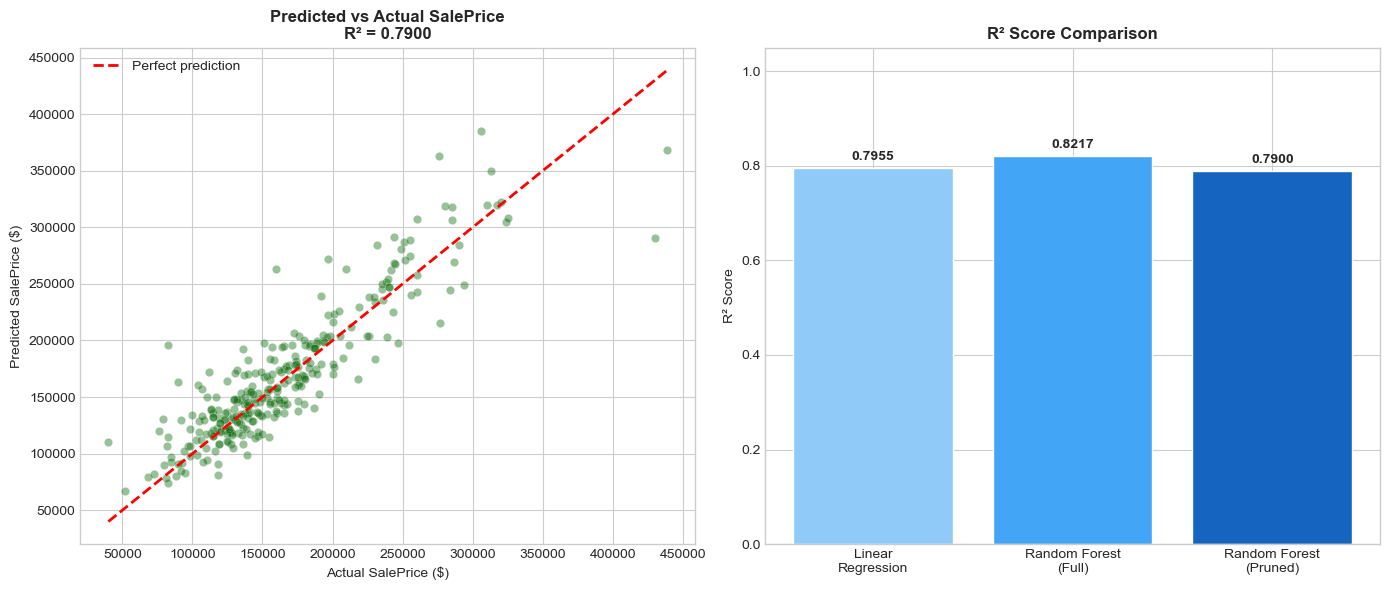

Figure 9: Final model evaluation


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_pruned, alpha=0.4, color='#006400', edgecolors='white', linewidths=0.3)
min_val = min(y_test.min(), y_pred_pruned.min())
max_val = max(y_test.max(), y_pred_pruned.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Predicted vs Actual SalePrice\nR² = {r2_p:.4f}', fontweight='bold')
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].legend()

models = ['Linear\nRegression', 'Random Forest\n(Full)', 'Random Forest\n(Pruned)']
r2_vals = [r2_lr, r2_rf, r2_p]
colors = ['#90CAF9', '#42A5F5', '#1565C0']
bars = axes[1].bar(models, r2_vals, color=colors, edgecolor='white')
axes[1].set_title('R² Score Comparison', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print('Figure 9: Final model evaluation')

In [24]:
cv_scores = cross_val_score(rf_pruned, X[important_features], y, cv=5, scoring='r2')
print('5-Fold Cross Validation (Pruned Random Forest)')
print(f'CV R² Scores : {cv_scores.round(4)}')
print(f'Mean R²      : {cv_scores.mean():.4f}')
print(f'Std Dev      : {cv_scores.std():.4f}')

5-Fold Cross Validation (Pruned Random Forest)
CV R² Scores : [0.8081 0.8421 0.8386 0.8447 0.7993]
Mean R²      : 0.8266
Std Dev      : 0.0190


In [25]:
sample = X_test_pruned.head(5)
sample_actual = y_test.head(5).values
sample_pred   = rf_pruned.predict(sample)

sample_df = pd.DataFrame({
    'Actual SalePrice ($)':    [f'{v:,.0f}' for v in sample_actual],
    'Predicted SalePrice ($)': [f'{v:,.0f}' for v in sample_pred],
    'Difference ($)':          [f'{abs(a-p):,.0f}' for a, p in zip(sample_actual, sample_pred)]
})
print('Sample Predictions:')
print(sample_df.to_string(index=False))

Sample Predictions:
Actual SalePrice ($) Predicted SalePrice ($) Difference ($)
             197,000                 271,758         74,758
              76,000                 119,866         43,866
             131,500                 145,284         13,784
             175,000                 160,322         14,678
             127,000                 121,108          5,892


Summary and Conclusion

In [26]:
print('       HOUSE PRICE PREDICTION — FINAL SUMMARY')
print(f'Dataset          : House Prices (Kaggle)')
print(f'Records used     : {len(df_encoded)}')
print(f'Features selected: {len(selected_features)}')
print(f'Best Model       : Random Forest Regressor (Full)')
print(f'RMSE             : ${rmse_rf:,.2f}')
print(f'MAE              : ${mae_rf:,.2f}')
print(f'R² Score         : {r2_rf:.4f} ({r2_rf*100:.1f}% variance explained)')
print('Conclusion: The full Random Forest Regressoin gave the best accuracy,')
print('explaining about 82% of the variance in house prices. The pruned')
print('version remained stable across folds (mean R² ≈ 0.83), showing')
print('consistent generalization with fewer features.')



       HOUSE PRICE PREDICTION — FINAL SUMMARY
Dataset          : House Prices (Kaggle)
Records used     : 1448
Features selected: 20
Best Model       : Random Forest Regressor (Full)
RMSE             : $24,939.70
MAE              : $17,278.23
R² Score         : 0.8217 (82.2% variance explained)
Conclusion: The full Random Forest Regressoin gave the best accuracy,
explaining about 82% of the variance in house prices. The pruned
version remained stable across folds (mean R² ≈ 0.83), showing
consistent generalization with fewer features.
